In [1]:
import requests
import pandas as pd
import folium
import time
import json

print("✅ Packages importés avec succès")
print(f"Version pandas : {pd.__version__}")
print(f"Version requests : {requests.__version__}")

✅ Packages importés avec succès
Version pandas : 2.3.3
Version requests : 2.32.5


In [2]:
# ===== TEST API OPEN-METEO (Météo) =====

print("🌤️  TEST API OPEN-METEO")
print("=" * 60)

# Coordonnées de Pau
lat_pau = 43.3
lon_pau = -0.37

url_meteo = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": lat_pau,
    "longitude": lon_pau,
    "current": "temperature_2m,relative_humidity_2m,wind_speed_10m",
    "hourly": "temperature_2m",
    "timezone": "Europe/Paris"
}

response = requests.get(url_meteo, params=params)
print(f"Status: {response.status_code}")

if response.status_code == 200:
    data = response.json()
    print(f"\n✅ Données météo Pau reçues")
    print(f"\n📊 Température actuelle : {data['current']['temperature_2m']}°C")
    print(f"💧 Humidité : {data['current']['relative_humidity_2m']}%")
    print(f"💨 Vent : {data['current']['wind_speed_10m']} km/h")
else:
    print(f"❌ Erreur : {response.status_code}")

🌤️  TEST API OPEN-METEO
Status: 200

✅ Données météo Pau reçues

📊 Température actuelle : 11.8°C
💧 Humidité : 76%
💨 Vent : 12.5 km/h


In [3]:
# ===== TEST API OPEN-METEO AIR QUALITY =====

print("\n🏭 TEST API OPEN-METEO AIR QUALITY")
print("=" * 60)

url_air = "https://air-quality-api.open-meteo.com/v1/air-quality"
params = {
    "latitude": lat_pau,
    "longitude": lon_pau,
    "current": "pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,european_aqi",
    "timezone": "Europe/Paris"
}

response = requests.get(url_air, params=params)
print(f"Status: {response.status_code}")

if response.status_code == 200:
    data = response.json()
    print(f"\n✅ Données qualité de l'air Pau reçues")
    
    current = data['current']
    print(f"\n📊 Indice qualité air européen (AQI) : {current.get('european_aqi')}")
    print(f"💨 PM2.5 : {current.get('pm2_5')} µg/m³")
    print(f"💨 PM10 : {current.get('pm10')} µg/m³")
    print(f"🌫️  Ozone : {current.get('ozone')} µg/m³")
    print(f"🏭 NO2 : {current.get('nitrogen_dioxide')} µg/m³")
    
    print(f"\n✅ PROJET VIABLE : Météo + Pollution avec Open-Meteo !")
else:
    print(f"❌ Erreur : {response.status_code}")


🏭 TEST API OPEN-METEO AIR QUALITY
Status: 200

✅ Données qualité de l'air Pau reçues

📊 Indice qualité air européen (AQI) : 30
💨 PM2.5 : 1.8 µg/m³
💨 PM10 : 3.9 µg/m³
🌫️  Ozone : 75.0 µg/m³
🏭 NO2 : 2.7 µg/m³

✅ PROJET VIABLE : Météo + Pollution avec Open-Meteo !


In [4]:
# ===== LISTE DES 10 VILLES =====

villes_france = {
    "Paris": {"lat": 48.8566, "lon": 2.3522},
    "Marseille": {"lat": 43.2965, "lon": 5.3698},
    "Lyon": {"lat": 45.7640, "lon": 4.8357},
    "Toulouse": {"lat": 43.6047, "lon": 1.4442},
    "Nice": {"lat": 43.7102, "lon": 7.2620},
    "Nantes": {"lat": 47.2184, "lon": -1.5536},
    "Strasbourg": {"lat": 48.5734, "lon": 7.7521},
    "Bordeaux": {"lat": 44.8378, "lon": -0.5792},
    "Lille": {"lat": 50.6292, "lon": 3.0573},
    "Pau": {"lat": 43.2951, "lon": -0.3708}
}

print("✅ 10 villes françaises définies")
print("\n📍 Liste des villes :")
for ville, coords in villes_france.items():
    print(f"  - {ville}: lat={coords['lat']}, lon={coords['lon']}")

✅ 10 villes françaises définies

📍 Liste des villes :
  - Paris: lat=48.8566, lon=2.3522
  - Marseille: lat=43.2965, lon=5.3698
  - Lyon: lat=45.764, lon=4.8357
  - Toulouse: lat=43.6047, lon=1.4442
  - Nice: lat=43.7102, lon=7.262
  - Nantes: lat=47.2184, lon=-1.5536
  - Strasbourg: lat=48.5734, lon=7.7521
  - Bordeaux: lat=44.8378, lon=-0.5792
  - Lille: lat=50.6292, lon=3.0573
  - Pau: lat=43.2951, lon=-0.3708


In [5]:
# ===== FONCTION EXTRACTION DONNÉES COMPLÈTES =====

def get_ville_data(ville_name, lat, lon):
    """
    Récupère météo + pollution pour une ville
    """
    
    # MÉTÉO
    url_meteo = "https://api.open-meteo.com/v1/forecast"
    params_meteo = {
        "latitude": lat,
        "longitude": lon,
        "current": "temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation",
        "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum",
        "timezone": "Europe/Paris",
        "forecast_days": 7
    }
    
    # POLLUTION
    url_air = "https://air-quality-api.open-meteo.com/v1/air-quality"
    params_air = {
        "latitude": lat,
        "longitude": lon,
        "current": "pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,european_aqi",
        "timezone": "Europe/Paris"
    }
    
    result = {"ville": ville_name, "lat": lat, "lon": lon}
    
    # Récupération météo
    try:
        r_meteo = requests.get(url_meteo, params=params_meteo)
        if r_meteo.status_code == 200:
            data_meteo = r_meteo.json()
            result["meteo_current"] = data_meteo.get("current", {})
            result["meteo_daily"] = data_meteo.get("daily", {})
        time.sleep(0.3)
    except Exception as e:
        print(f"  ⚠️  Erreur météo {ville_name}: {e}")
    
    # Récupération pollution
    try:
        r_air = requests.get(url_air, params=params_air)
        if r_air.status_code == 200:
            data_air = r_air.json()
            result["pollution"] = data_air.get("current", {})
        time.sleep(0.3)
    except Exception as e:
        print(f"  ⚠️  Erreur pollution {ville_name}: {e}")
    
    return result

print("✅ Fonction d'extraction créée")

✅ Fonction d'extraction créée


In [6]:
# ===== EXTRACTION 10 VILLES =====

print("🌍 EXTRACTION DONNÉES 10 VILLES FRANCE")
print("=" * 60)

all_data = []

for ville, coords in villes_france.items():
    print(f"\n📍 {ville}...")
    data = get_ville_data(ville, coords["lat"], coords["lon"])
    all_data.append(data)
    print(f"  ✅ Données récupérées")

print(f"\n✅ {len(all_data)} villes extraites avec succès")

🌍 EXTRACTION DONNÉES 10 VILLES FRANCE

📍 Paris...
  ✅ Données récupérées

📍 Marseille...
  ✅ Données récupérées

📍 Lyon...
  ✅ Données récupérées

📍 Toulouse...
  ✅ Données récupérées

📍 Nice...
  ✅ Données récupérées

📍 Nantes...
  ✅ Données récupérées

📍 Strasbourg...
  ✅ Données récupérées

📍 Bordeaux...
  ✅ Données récupérées

📍 Lille...
  ✅ Données récupérées

📍 Pau...
  ✅ Données récupérées

✅ 10 villes extraites avec succès


In [7]:
# ===== CONVERSION EN DATAFRAMES =====

print("📊 CRÉATION DES DATAFRAMES")
print("=" * 60)

# DataFrame météo actuelle
meteo_data = []
for city in all_data:
    meteo = city.get("meteo_current", {})
    meteo_data.append({
        "ville": city["ville"],
        "lat": city["lat"],
        "lon": city["lon"],
        "temperature": meteo.get("temperature_2m"),
        "humidite": meteo.get("relative_humidity_2m"),
        "vent": meteo.get("wind_speed_10m"),
        "precipitation": meteo.get("precipitation", 0)
    })

df_meteo = pd.DataFrame(meteo_data)

# DataFrame pollution actuelle
pollution_data = []
for city in all_data:
    poll = city.get("pollution", {})
    pollution_data.append({
        "ville": city["ville"],
        "aqi": poll.get("european_aqi"),
        "pm2_5": poll.get("pm2_5"),
        "pm10": poll.get("pm10"),
        "ozone": poll.get("ozone"),
        "no2": poll.get("nitrogen_dioxide"),
        "co": poll.get("carbon_monoxide")
    })

df_pollution = pd.DataFrame(pollution_data)

# DataFrame complet (merge)
df_complet = pd.merge(df_meteo, df_pollution, on="ville")

print(f"\n✅ DataFrames créés :")
print(f"  - Météo : {df_meteo.shape}")
print(f"  - Pollution : {df_pollution.shape}")
print(f"  - Complet : {df_complet.shape}")

print(f"\n📋 Aperçu données complètes :")
print(df_complet)



print(f"\n📈 STATISTIQUES :")
print(f"\n🌡️  Températures :")
print(f"  Plus chaude : {df_complet.loc[df_complet['temperature'].idxmax(), 'ville']} ({df_complet['temperature'].max():.1f}°C)")
print(f"  Plus froide : {df_complet.loc[df_complet['temperature'].idxmin(), 'ville']} ({df_complet['temperature'].min():.1f}°C)")

print(f"\n🏭 Pollution (AQI) :")
print(f"  Plus polluée : {df_complet.loc[df_complet['aqi'].idxmax(), 'ville']} (AQI: {df_complet['aqi'].max()})")
print(f"  Plus propre : {df_complet.loc[df_complet['aqi'].idxmin(), 'ville']} (AQI: {df_complet['aqi'].min()})")



📊 CRÉATION DES DATAFRAMES

✅ DataFrames créés :
  - Météo : (10, 7)
  - Pollution : (10, 7)
  - Complet : (10, 13)

📋 Aperçu données complètes :
        ville      lat     lon  temperature  humidite  vent  precipitation  \
0       Paris  48.8566  2.3522          6.7        84   9.8            0.0   
1   Marseille  43.2965  5.3698          9.9        74  14.1            0.0   
2        Lyon  45.7640  4.8357          2.0        90   8.4            0.1   
3    Toulouse  43.6047  1.4442         11.0        84  17.3            0.0   
4        Nice  43.7102  7.2620          8.2        52   4.1            0.0   
5      Nantes  47.2184 -1.5536         12.1        87  24.3            0.3   
6  Strasbourg  48.5734  7.7521          1.0        94  13.5            0.0   
7    Bordeaux  44.8378 -0.5792         13.0        84  17.7            0.1   
8       Lille  50.6292  3.0573          2.2        95  10.1            0.0   
9         Pau  43.2951 -0.3708         11.8        76  12.5            0.0 

📊 CRÉATION DES GRAPHIQUES


C:\Users\Pascal\AppData\Local\Temp\ipykernel_2228\3826118277.py:54: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Pascal\AppData\Local\Temp\ipykernel_2228\3826118277.py:54: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Pascal\AppData\Local\Temp\ipykernel_2228\3826118277.py:54: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Pascal\AppData\Local\Temp\ipykernel_2228\3826118277.py:54: UserWarning: Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Pascal\AppData\Local\Temp\ipykernel_2228\3826118277.py:55: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  plt.savefig('dashboard_meteo_pollution.png', dpi=150, bbox_inches='tight')
C:\Users\Pascal\AppData\Local\Temp\ipykernel_2228\3826118277.py:55: UserWarning: Glyph 127981 


✅ Graphique sauvegardé : dashboard_meteo_pollution.png


C:\Users\Pascal\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Pascal\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Pascal\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Pascal\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


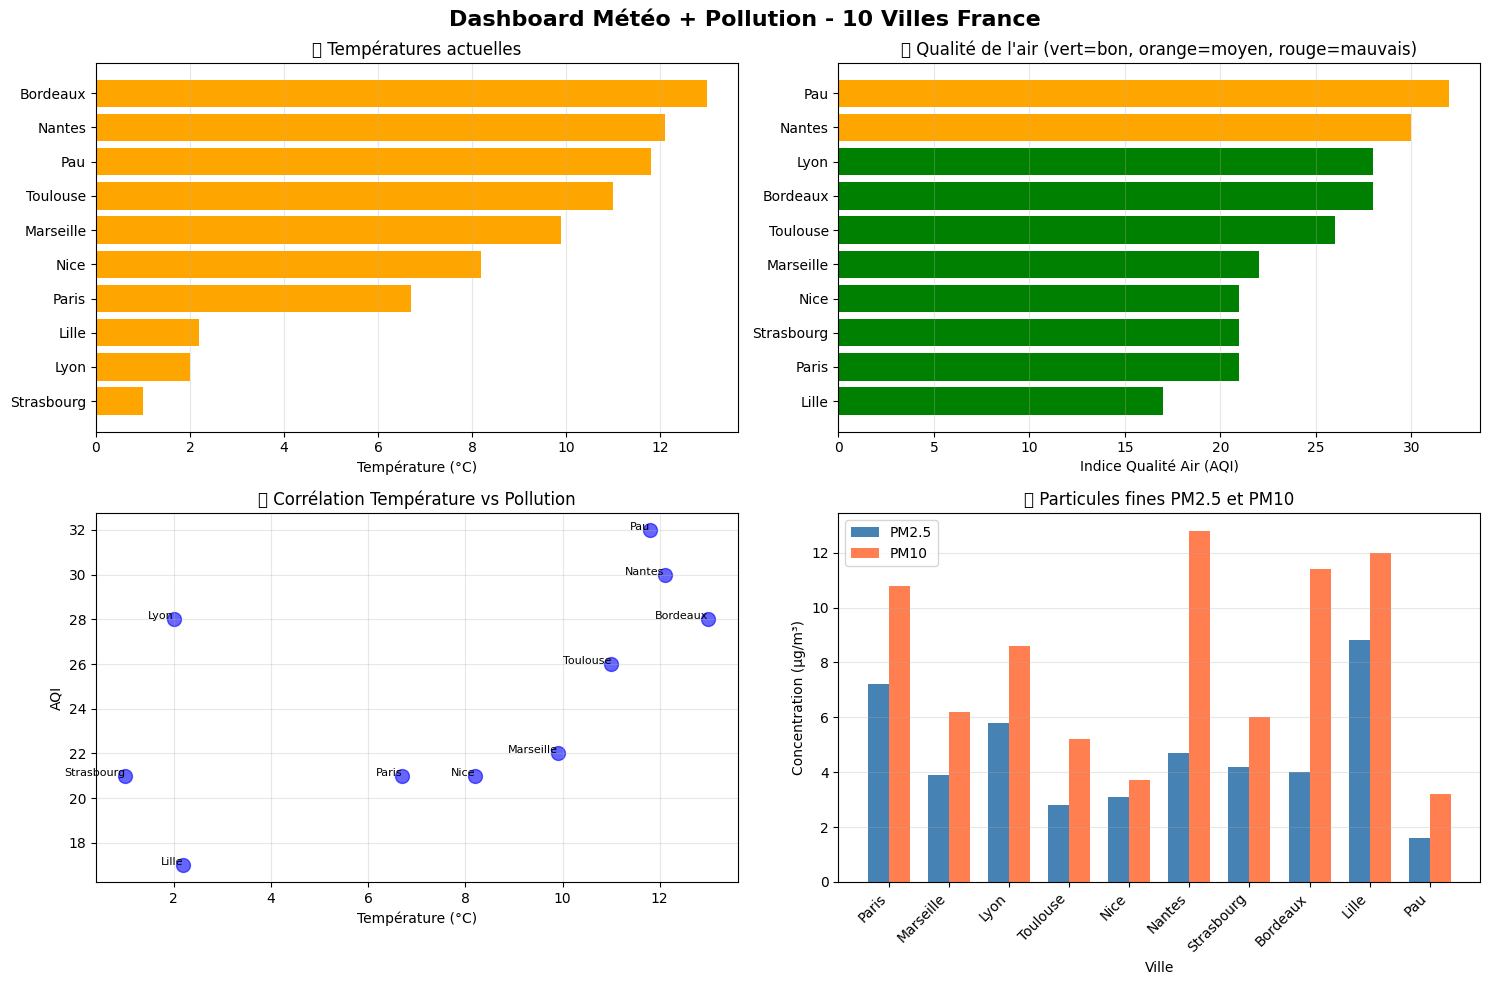


📊 Dashboard créé avec succès !


In [8]:
# ===== VISUALISATIONS =====

import matplotlib.pyplot as plt

print("📊 CRÉATION DES GRAPHIQUES")
print("=" * 60)

# Configuration
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Dashboard Météo + Pollution - 10 Villes France', fontsize=16, fontweight='bold')

# 1. Températures par ville
ax1 = axes[0, 0]
df_complet_sorted = df_complet.sort_values('temperature', ascending=True)
ax1.barh(df_complet_sorted['ville'], df_complet_sorted['temperature'], color='orange')
ax1.set_xlabel('Température (°C)')
ax1.set_title('🌡️ Températures actuelles')
ax1.grid(axis='x', alpha=0.3)

# 2. Qualité de l'air (AQI) par ville
ax2 = axes[0, 1]
df_complet_sorted_aqi = df_complet.sort_values('aqi', ascending=True)
colors_aqi = ['green' if x < 30 else 'orange' if x < 50 else 'red' for x in df_complet_sorted_aqi['aqi']]
ax2.barh(df_complet_sorted_aqi['ville'], df_complet_sorted_aqi['aqi'], color=colors_aqi)
ax2.set_xlabel('Indice Qualité Air (AQI)')
ax2.set_title('🏭 Qualité de l\'air (vert=bon, orange=moyen, rouge=mauvais)')
ax2.grid(axis='x', alpha=0.3)

# 3. Corrélation Température vs Pollution
ax3 = axes[1, 0]
ax3.scatter(df_complet['temperature'], df_complet['aqi'], s=100, alpha=0.6, color='blue')
for i, ville in enumerate(df_complet['ville']):
    ax3.annotate(ville, (df_complet['temperature'].iloc[i], df_complet['aqi'].iloc[i]), 
                 fontsize=8, ha='right')
ax3.set_xlabel('Température (°C)')
ax3.set_ylabel('AQI')
ax3.set_title('🔍 Corrélation Température vs Pollution')
ax3.grid(alpha=0.3)

# 4. PM2.5 vs PM10
ax4 = axes[1, 1]
x = range(len(df_complet))
width = 0.35
ax4.bar([i - width/2 for i in x], df_complet['pm2_5'], width, label='PM2.5', color='steelblue')
ax4.bar([i + width/2 for i in x], df_complet['pm10'], width, label='PM10', color='coral')
ax4.set_xlabel('Ville')
ax4.set_ylabel('Concentration (µg/m³)')
ax4.set_title('💨 Particules fines PM2.5 et PM10')
ax4.set_xticks(x)
ax4.set_xticklabels(df_complet['ville'], rotation=45, ha='right')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('dashboard_meteo_pollution.png', dpi=150, bbox_inches='tight')
print("\n✅ Graphique sauvegardé : dashboard_meteo_pollution.png")
plt.show()

print("\n📊 Dashboard créé avec succès !")

In [10]:
import streamlit as st
import requests
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
import time

# Configuration page
st.set_page_config(
    page_title="Météo + Pollution France",
    page_icon="🌤️",
    layout="wide"
)

# Titre
st.title("🌤️ Dashboard Météo & Pollution - France")
st.markdown("*Données temps réel via Open-Meteo API*")
st.markdown("---")

# ===== DONNÉES DES VILLES =====
VILLES_FRANCE = {
    "Paris": {"lat": 48.8566, "lon": 2.3522},
    "Marseille": {"lat": 43.2965, "lon": 5.3698},
    "Lyon": {"lat": 45.7640, "lon": 4.8357},
    "Toulouse": {"lat": 43.6047, "lon": 1.4442},
    "Nice": {"lat": 43.7102, "lon": 7.2620},
    "Nantes": {"lat": 47.2184, "lon": -1.5536},
    "Strasbourg": {"lat": 48.5734, "lon": 7.7521},
    "Bordeaux": {"lat": 44.8378, "lon": -0.5792},
    "Lille": {"lat": 50.6292, "lon": 3.0573},
    "Pau": {"lat": 43.2951, "lon": -0.3708}
}

# ===== FONCTIONS API =====
@st.cache_data(ttl=3600)  # Cache 1h
def get_meteo_data(lat, lon):
    """Récupère données météo"""
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": lat,
        "longitude": lon,
        "current": "temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,weather_code",
        "hourly": "temperature_2m",
        "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum",
        "timezone": "Europe/Paris",
        "forecast_days": 7
    }
    
    response = requests.get(url, params=params)
    if response.status_code == 200:
        return response.json()
    return None

@st.cache_data(ttl=3600)
def get_pollution_data(lat, lon):
    """Récupère données pollution"""
    url = "https://air-quality-api.open-meteo.com/v1/air-quality"
    params = {
        "latitude": lat,
        "longitude": lon,
        "current": "pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,european_aqi",
        "timezone": "Europe/Paris"
    }
    
    response = requests.get(url, params=params)
    if response.status_code == 200:
        return response.json()
    return None

@st.cache_data(ttl=3600)
def get_all_cities_data():
    """Récupère données toutes villes"""
    all_data = []
    
    progress_bar = st.progress(0)
    status_text = st.empty()
    
    for i, (ville, coords) in enumerate(VILLES_FRANCE.items()):
        status_text.text(f"Chargement {ville}...")
        
        meteo = get_meteo_data(coords["lat"], coords["lon"])
        pollution = get_pollution_data(coords["lat"], coords["lon"])
        
        if meteo and pollution:
            data = {
                "ville": ville,
                "lat": coords["lat"],
                "lon": coords["lon"],
                "temperature": meteo["current"]["temperature_2m"],
                "humidite": meteo["current"]["relative_humidity_2m"],
                "vent": meteo["current"]["wind_speed_10m"],
                "precipitation": meteo["current"].get("precipitation", 0),
                "aqi": pollution["current"]["european_aqi"],
                "pm2_5": pollution["current"]["pm2_5"],
                "pm10": pollution["current"]["pm10"],
                "ozone": pollution["current"]["ozone"],
                "no2": pollution["current"]["nitrogen_dioxide"]
            }
            all_data.append(data)
        
        progress_bar.progress((i + 1) / len(VILLES_FRANCE))
        time.sleep(0.3)
    
    progress_bar.empty()
    status_text.empty()
    
    return pd.DataFrame(all_data)

# ===== SIDEBAR =====
st.sidebar.header("🎯 Navigation")

mode = st.sidebar.radio(
    "Choisir le mode :",
    ["📊 Vue d'ensemble", "🏙️ Détail ville"]
)

# ===== MODE VUE D'ENSEMBLE =====
if mode == "📊 Vue d'ensemble":
    st.header("📊 Vue d'ensemble - 10 villes")
    
    # Chargement données
    with st.spinner("Chargement des données..."):
        df = get_all_cities_data()
    
    st.success(f"✅ {len(df)} villes chargées - Dernière mise à jour : {datetime.now().strftime('%H:%M:%S')}")
    
    # Métriques globales
    col1, col2, col3, col4 = st.columns(4)
    
    with col1:
        st.metric(
            "🌡️ Ville la plus chaude",
            f"{df.loc[df['temperature'].idxmax(), 'ville']}",
            f"{df['temperature'].max():.1f}°C"
        )
    
    with col2:
        st.metric(
            "❄️ Ville la plus froide",
            f"{df.loc[df['temperature'].idxmin(), 'ville']}",
            f"{df['temperature'].min():.1f}°C"
        )
    
    with col3:
        st.metric(
            "🏭 Ville la plus polluée",
            f"{df.loc[df['aqi'].idxmax(), 'ville']}",
            f"AQI {df['aqi'].max()}"
        )
    
    with col4:
        st.metric(
            "🌿 Ville la plus propre",
            f"{df.loc[df['aqi'].idxmin(), 'ville']}",
            f"AQI {df['aqi'].min()}"
        )
    
    st.markdown("---")
    
    # Graphiques
    col_left, col_right = st.columns(2)
    
    with col_left:
        st.subheader("🌡️ Températures")
        fig_temp = px.bar(
            df.sort_values('temperature', ascending=True),
            x='temperature',
            y='ville',
            orientation='h',
            color='temperature',
            color_continuous_scale='RdYlBu_r',
            labels={'temperature': 'Température (°C)'},
            height=400
        )
        fig_temp.update_layout(showlegend=False)
        st.plotly_chart(fig_temp, use_container_width=True)
    
    with col_right:
        st.subheader("🏭 Qualité de l'air (AQI)")
        
        # Couleurs selon AQI
        colors = ['green' if x < 30 else 'orange' if x < 50 else 'red' for x in df['aqi']]
        
        fig_aqi = go.Figure(go.Bar(
            x=df.sort_values('aqi', ascending=True)['aqi'],
            y=df.sort_values('aqi', ascending=True)['ville'],
            orientation='h',
            marker=dict(color=colors)
        ))
        fig_aqi.update_layout(
            xaxis_title="Indice AQI",
            height=400,
            showlegend=False
        )
        st.plotly_chart(fig_aqi, use_container_width=True)
    
    # Carte France
    st.subheader("🗺️ Carte des villes")
    
    fig_map = px.scatter_geo(
        df,
        lat='lat',
        lon='lon',
        text='ville',
        size='aqi',
        color='temperature',
        color_continuous_scale='RdYlBu_r',
        hover_name='ville',
        hover_data={
            'temperature': ':.1f',
            'aqi': True,
            'lat': False,
            'lon': False
        },
        scope='europe',
        height=500
    )
    
    fig_map.update_geos(
        center=dict(lat=46.5, lon=2.5),
        projection_scale=6,
        showland=True,
        landcolor='lightgray'
    )
    
    st.plotly_chart(fig_map, use_container_width=True)
    
    # Tableau données
    st.subheader("📋 Données détaillées")
    st.dataframe(
        df.style.background_gradient(subset=['temperature'], cmap='RdYlBu_r')
              .background_gradient(subset=['aqi'], cmap='RdYlGn_r'),
        use_container_width=True
    )

# ===== MODE DÉTAIL VILLE =====
else:
    st.header("🏙️ Détail par ville")
    
    # Sélection ville
    ville_selectionnee = st.selectbox(
        "Choisir une ville :",
        list(VILLES_FRANCE.keys())
    )
    
    coords = VILLES_FRANCE[ville_selectionnee]
    
    # Chargement données
    with st.spinner(f"Chargement données {ville_selectionnee}..."):
        meteo = get_meteo_data(coords["lat"], coords["lon"])
        pollution = get_pollution_data(coords["lat"], coords["lon"])
    
    if meteo and pollution:
        st.success(f"✅ Données chargées - {datetime.now().strftime('%H:%M:%S')}")
        
        # Métriques actuelles
        col1, col2, col3, col4 = st.columns(4)
        
        with col1:
            st.metric(
                "🌡️ Température",
                f"{meteo['current']['temperature_2m']:.1f}°C"
            )
        
        with col2:
            st.metric(
                "💧 Humidité",
                f"{meteo['current']['relative_humidity_2m']}%"
            )
        
        with col3:
            st.metric(
                "💨 Vent",
                f"{meteo['current']['wind_speed_10m']:.1f} km/h"
            )
        
        with col4:
            aqi = pollution['current']['european_aqi']
            aqi_label = "Bon" if aqi < 30 else "Moyen" if aqi < 50 else "Mauvais"
            st.metric(
                "🏭 AQI",
                aqi,
                aqi_label
            )
        
        st.markdown("---")
        
        # Prévisions 7 jours
        st.subheader("📅 Prévisions 7 jours")
        
        daily_data = pd.DataFrame({
            'Date': pd.to_datetime(meteo['daily']['time']),
            'Temp Max': meteo['daily']['temperature_2m_max'],
            'Temp Min': meteo['daily']['temperature_2m_min'],
            'Précipitations': meteo['daily']['precipitation_sum']
        })
        
        fig_previsions = go.Figure()
        
        fig_previsions.add_trace(go.Scatter(
            x=daily_data['Date'],
            y=daily_data['Temp Max'],
            name='Temp Max',
            line=dict(color='red')
        ))
        
        fig_previsions.add_trace(go.Scatter(
            x=daily_data['Date'],
            y=daily_data['Temp Min'],
            name='Temp Min',
            line=dict(color='blue')
        ))
        
        fig_previsions.update_layout(
            xaxis_title="Date",
            yaxis_title="Température (°C)",
            height=400
        )
        
        st.plotly_chart(fig_previsions, use_container_width=True)
        
        # Détails pollution
        st.subheader("🏭 Détails pollution")
        
        col_poll1, col_poll2 = st.columns(2)
        
        with col_poll1:
            st.metric("PM2.5", f"{pollution['current']['pm2_5']:.1f} µg/m³")
            st.metric("PM10", f"{pollution['current']['pm10']:.1f} µg/m³")
            st.metric("Ozone", f"{pollution['current']['ozone']:.1f} µg/m³")
        
        with col_poll2:
            st.metric("NO2", f"{pollution['current']['nitrogen_dioxide']:.1f} µg/m³")
            st.metric("SO2", f"{pollution['current']['sulphur_dioxide']:.1f} µg/m³")
            st.metric("CO", f"{pollution['current']['carbon_monoxide']:.1f} µg/m³")

# Footer
st.markdown("---")
st.markdown("*Données fournies par Open-Meteo API | Mise à jour automatique toutes les heures*")

2026-01-08 12:00:56.411 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-08 12:00:56.412 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-08 12:00:56.641 
  command:

    streamlit run C:\Users\Pascal\AppData\Roaming\Python\Python314\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-01-08 12:00:56.641 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-08 12:00:56.642 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-08 12:00:56.642 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-08 12:00:56.643 Thread 'MainThread': missing ScriptRunContext! This warning can 

DeltaGenerator()

In [11]:
!streamlit run app_meteo_pollution.py

^C


In [ ]:
import streamlit as st
import requests
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
import time

In [ ]:
# ===== DONNÉES DES VILLES =====
VILLES_FRANCE = {
    "Paris": {"lat": 48.8566, "lon": 2.3522},
    "Marseille": {"lat": 43.2965, "lon": 5.3698},
    "Lyon": {"lat": 45.7640, "lon": 4.8357},
    "Toulouse": {"lat": 43.6047, "lon": 1.4442},
    "Nice": {"lat": 43.7102, "lon": 7.2620},
    "Nantes": {"lat": 47.2184, "lon": -1.5536},
    "Strasbourg": {"lat": 48.5734, "lon": 7.7521},
    "Bordeaux": {"lat": 44.8378, "lon": -0.5792},
    "Lille": {"lat": 50.6292, "lon": 3.0573},
    "Pau": {"lat": 43.2951, "lon": -0.3708}
}

In [ ]:
def extraire_meteo(df_villes):
    """
    Appelle l'API météo pour chaque ville du DataFrame
    Retourne un DataFrame avec lat, lon et données météo
    """
    meteo_list = []
    
    for index, row in df_villes.iterrows():
        # Appel API
        url = "https://api.open-meteo.com/v1/forecast"
        params = {
            "latitude": row['lat'],
            "longitude": row['lon'],
            "current": "temperature_2m,relative_humidity_2m,wind_speed_10m"
        }
        
        try:
            response = requests.get(url, params=params)
            
            if response.status_code == 200:
                data = response.json()
                current = data['current']
                
                # Construction ligne du DataFrame
                meteo_list.append({
                    'lat': row['lat'],
                    'lon': row['lon'],
                    'temperature': current['temperature_2m'],
                    'humidite': current['relative_humidity_2m'],
                    'vent': current['wind_speed_10m']
                })
            
            time.sleep(0.3)  # Respect limites API
            
        except Exception as e:
            st.warning(f"Erreur météo pour lat={row['lat']}, lon={row['lon']}: {e}")
    
    # Conversion en DataFrame
    df_meteo = pd.DataFrame(meteo_list)
    return df_meteo